In [1]:
import pandas as pd

# Load the labeled data we created in Week 1
labeled_df = pd.read_csv("data/labeled_criteria.csv")

print(f"Total criteria: {len(labeled_df)}")
print(f"\nLabel distribution:")
print(labeled_df["label"].value_counts())
print(f"\nSample data:")
print(labeled_df.head(3))

Total criteria: 1340

Label distribution:
label
exclusion    736
inclusion    604
Name: count, dtype: int64

Sample data:
        nct_id                                          criterion      label
0  NCT01518517  Patient from 1 to 55 years old (Children and a...  inclusion
1  NCT01518517  Patients with 1st ALL relapse, which could be ...  inclusion
2  NCT01518517  Patient previously treated with free E.Coli L-...  inclusion


In [2]:
from sklearn.model_selection import train_test_split

# Computers need numbers not words — 0 = inclusion, 1 = exclusion
labeled_df["label_num"] = labeled_df["label"].map({"inclusion": 0, "exclusion": 1})

# Split into training and testing sets
# 80% to train the model, 20% to test how well it learned
X_train, X_test, y_train, y_test = train_test_split(
    labeled_df["criterion"],
    labeled_df["label_num"],
    test_size=0.2,
    random_state=42
)

print(f"Training examples: {len(X_train)}")
print(f"Testing examples: {len(X_test)}")
print(f"\nTraining label distribution:")
print(y_train.value_counts())


Training examples: 1072
Testing examples: 268

Training label distribution:
label_num
1    590
0    482
Name: count, dtype: int64


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text to numbers using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# fit_transform on training data = learn the vocabulary + convert
# transform on test data = convert using same vocabulary (no learning)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Testing matrix shape: {X_test_tfidf.shape}")
print(f"\nWhat this means:")
print(f"Each of your {X_train_tfidf.shape[0]} training criteria is now")
print(f"represented as {X_train_tfidf.shape[1]} numbers")

Training matrix shape: (1072, 5000)
Testing matrix shape: (268, 5000)

What this means:
Each of your 1072 training criteria is now
represented as 5000 numbers


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report 

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.89      0.70      0.79       122
           1       0.79      0.92      0.85       146

    accuracy                           0.82       268
   macro avg       0.84      0.81      0.82       268
weighted avg       0.83      0.82      0.82       268



In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced'),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced')
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    print(f"\n📊 {name}")
    print(classification_report(y_test, y_pred))


📊 Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       122
           1       0.82      0.88      0.85       146

    accuracy                           0.83       268
   macro avg       0.83      0.82      0.83       268
weighted avg       0.83      0.83      0.83       268


📊 Naive Bayes
              precision    recall  f1-score   support

           0       0.87      0.70      0.77       122
           1       0.78      0.91      0.84       146

    accuracy                           0.81       268
   macro avg       0.82      0.80      0.81       268
weighted avg       0.82      0.81      0.81       268


📊 Random Forest
              precision    recall  f1-score   support

           0       0.89      0.66      0.75       122
           1       0.76      0.93      0.84       146

    accuracy                           0.81       268
   macro avg       0.83      0.79      0.80       268
weighted avg       

In [9]:
from sklearn.model_selection import GridSearchCV

model = LogisticRegression(class_weight='balanced')

params = {
    'C' : [0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'liblinear']
}

grid = GridSearchCV(model, params, cv=5, scoring='f1_macro', verbose=1)
grid.fit(X_train_tfidf, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

y_pred = grid.best_estimator_.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'C': 1, 'solver': 'liblinear'}
Best CV F1: 0.8516187496277983
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       122
           1       0.82      0.88      0.85       146

    accuracy                           0.83       268
   macro avg       0.83      0.82      0.83       268
weighted avg       0.83      0.83      0.83       268



In [10]:
import joblib 

joblib.dump(grid.best_estimator_, 'eligibility_classifier.pkl')

print("Model saved!")

Model saved!


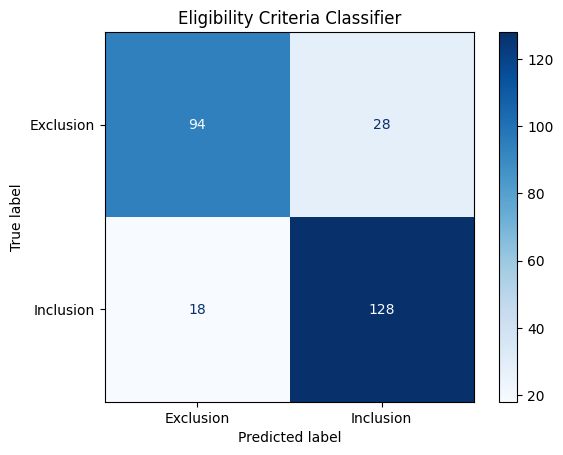

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)          # ✅ correct spelling
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                        display_labels=['Exclusion', 'Inclusion'])
disp.plot(cmap='Blues')
plt.title('Eligibility Criteria Classifier')
plt.show()

In [13]:
import joblib

joblib.dump(grid.best_estimator_, 'eligibility_classifier.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("Model saved!")

Model saved!
